# Node classification sweep performance - Cell type prediction

CosMx Pancrease data with cell types.

**Part 1: Hyperparmeter sweep**

Run hyperparameter sweep with script `hyperparameter.yaml` and config file: 

**Part 2: Robustness sweep**

Plots showing the performance for the graph classification on the CosMx Pancrease data with no diabetes and Type 1 Diabetes conditions.

- InterScale (GCN + Transformer)
- GCN
- PCATransformer



In [1]:
import os

# LRZ home
if os.path.exists("/dss/dsshome1/05/di93tig"):
    print('LRZ cluster')
    CLUSTER = 'LRZ'
    BASE_DIR_REPO = "/dss/dsshome1/05/di93tig/1_projects" 
    BASE_DIR_PROJECT = "/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale"
elif os.path.exists("/home/icb/francesca.drummer/"):
    print('HPC cluster')
    CLUSTER = 'HPC'
    BASE_DIR_REPO = "/home/icb/francesca.drummer/1-Projects/"
    BASE_DIR_PROJECT = ""
else:
    print('unkown')
    CLUSTER = 'unknown'
DATA = "melton25"

LRZ cluster


In [2]:
import sys
from pathlib import Path

# Add project root to path (go up 2 levels from notebook location)
project_root = Path(f'{BASE_DIR_REPO}/InterScale_reproducibility')
print(project_root)
sys.path.insert(0, str(project_root))

/dss/dsshome1/05/di93tig/1_projects/InterScale_reproducibility


In [3]:
import wandb
wandb.login()

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: francesca-drummer to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [6]:
import pandas as pd
# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt
from src.wandb import Wandb_evaluation, plot_f1_across_seeds, plot_class_f1_comparison, set_plot_configs
from InterScale.config import load_config, config_from_wandb_run

ImportError: cannot import name 'config_from_wandb_run' from 'InterScale.config' (/dss/dsshome1/05/di93tig/1_projects/GT-long-range-niches/src/InterScale/config/__init__.py)

In [ ]:
import yaml
import matplotlib.pyplot as plt
import scanpy as sc

with open(os.path.join(BASE_DIR_REPO, "InterScale_reproducibility/figures/config.yml"), "r") as f:
    config = yaml.safe_load(f)

PALETTE = config["palettes"]["continuous"]
CELL_TYPE_COLORS = config["palettes"][DATA]

## Hyperparameter sweep

Evaluation of node-classification (Cell type) hyperparameter sweep.

In [ ]:
CLASSES = ['Alpha', 'Acinar', 'Beta', 'Ductal', 'Endocrine', 'Immune', 'Mast', 'Beta', 'Endothelial', 'Fibroblasts']

### Load WandB IDs

In [ ]:
GNN_sweep = "tixesx9b"
Dual_sweep = "d9lf50og"

In [ ]:
SWEEP_GOAL = 'hyperparameter'

In [9]:
GNN_wandb = Wandb_evaluation("GCN", GNN_sweep, True, False, SWEEP_GOAL, CLASSES)
Dual_wandb = Wandb_evaluation("InterScale", Dual_sweep, True, True, SWEEP_GOAL, CLASSES)

In [10]:
GNN_wandb.get_dataframe().head()

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_acc,...,test_f1_class_Mast,test_f1_class_Endothelial,n_embed,lr,wd,lr_warmup,batch_size,LC_num_layers,LC_hidden_dim,LC_dropout
0,eo8zf316,melton25_clas_node_44_GCN_,44,finished,0.5,110,None,119.609158,31545,0.152462,...,0.000000,0.071304,16,0.010,0.010,10,16,1,64,0.0
1,8iynilij,melton25_clas_node_44_GCN_,44,finished,0.5,110,None,118.837533,126153,0.384902,...,0.000000,0.050000,64,0.010,0.100,30,32,1,128,0.3
2,jvca3zu7,melton25_clas_node_44_GCN_,44,finished,0.5,110,None,157.203672,31545,0.425476,...,0.000000,0.091667,16,0.001,0.000,10,32,1,128,0.0
3,anmc5420,melton25_clas_node_44_GCN_,44,finished,0.0,110,None,413.558504,31545,0.712727,...,0.274644,0.514756,16,0.001,0.000,20,64,1,512,0.0
4,9j7c4lcv,melton25_clas_node_44_GCN_,44,finished,0.0,110,None,145.181081,31545,0.708634,...,0.264742,0.525582,16,0.010,0.001,10,32,1,512,0.1


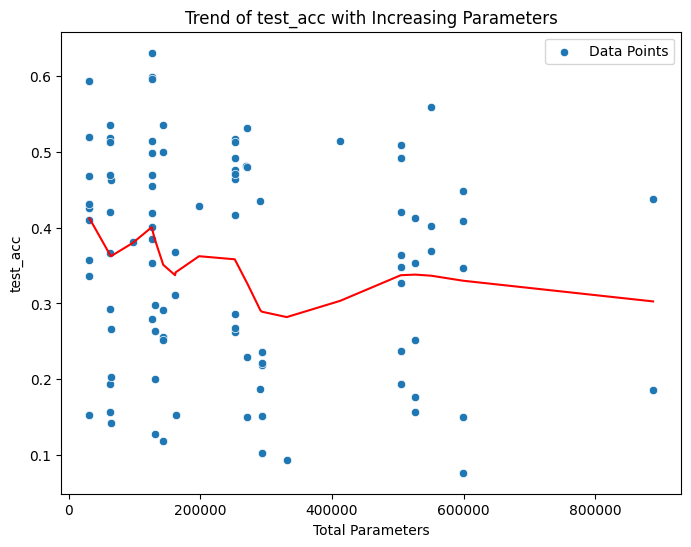

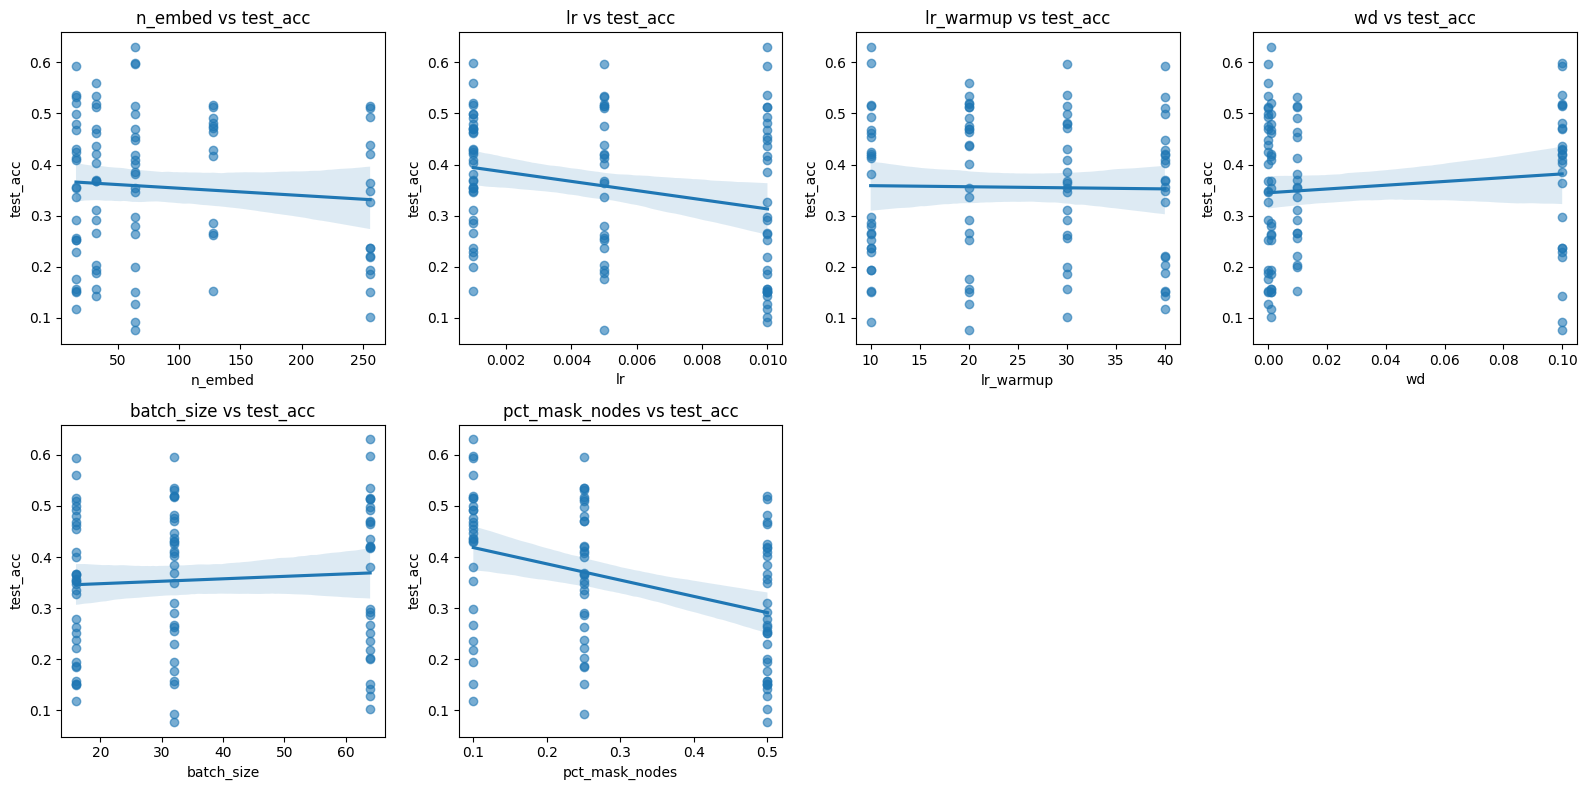

Saved figures to /dss/dsshome1/05/di93tig/1_projects/InterScale_reproducibility/figures/melton25/node_class


In [11]:
GNN_wandb.plot_parameter_space(metric = 'test_acc', relevant_params = GNN_wandb.hyperparameters, exclude_parameters = {"pct_mask_nodes":[0.0]}, save_path = f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/node_class")

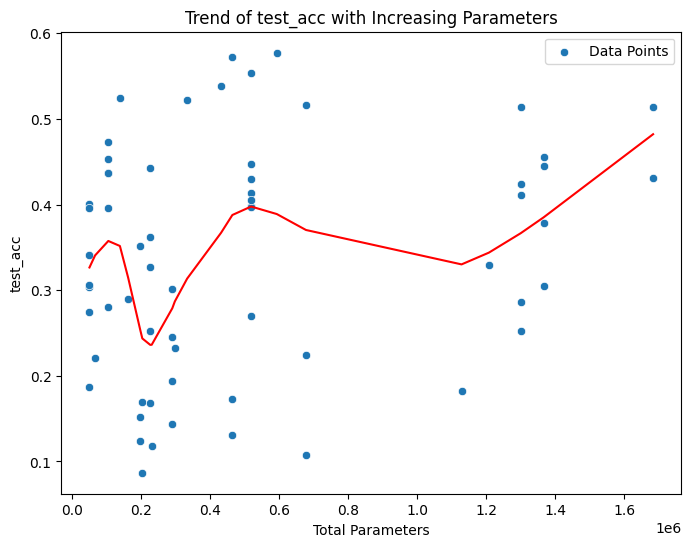

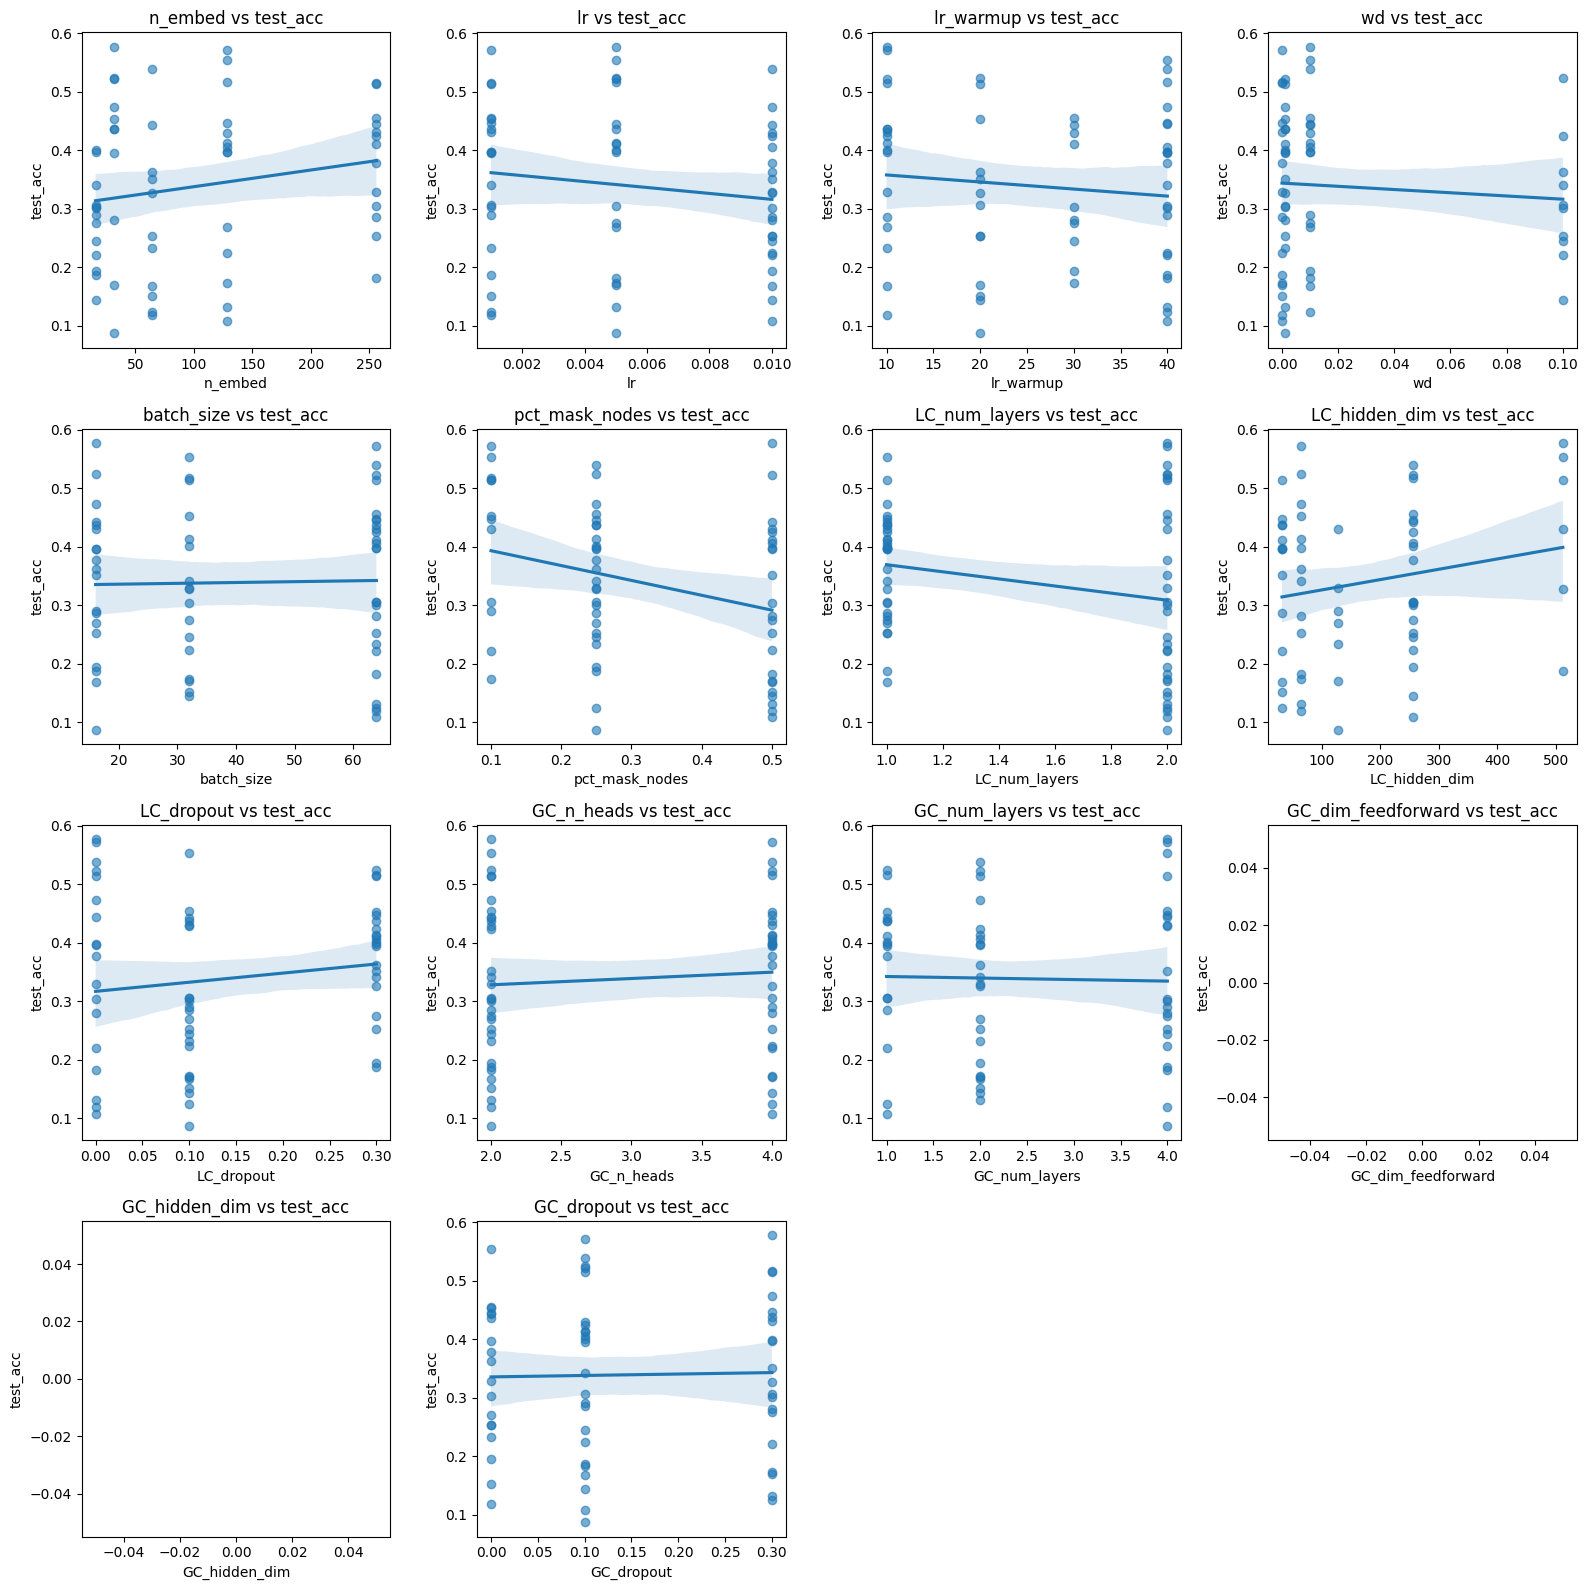

In [12]:
relevant_params = Dual_wandb.hyperparameters + Dual_wandb.local_component_params + Dual_wandb.global_component_params
Dual_wandb.plot_parameter_space(metric = 'test_acc', relevant_params = relevant_params, exclude_parameters = {"pct_mask_nodes":[0.0]})

### Best model selection

In [26]:
df = Dual_wandb.filter_runs(exclude_parameters = {"pct_mask_nodes":[0.0]})
df.head()

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_acc,...,lr_warmup,batch_size,LC_num_layers,LC_hidden_dim,LC_dropout,GC_n_heads,GC_num_layers,GC_dim_feedforward,GC_hidden_dim,GC_dropout
0,sysappn2,dual_melton25_clas_node_44_GCN_self-attn-trans...,44,finished,0.50,110,None,205.602434,197842,0.151653,...,20,32,2,32,0.1,2,2,None,None,0.0
1,4um0v8yu,dual_melton25_clas_node_44_GCN_self-attn-trans...,44,finished,0.10,110,None,160.353546,464786,0.173032,...,30,32,2,64,0.1,4,2,None,None,0.3
2,g2mx3fkm,dual_melton25_clas_node_44_GCN_self-attn-trans...,44,finished,0.25,110,None,182.710215,105586,0.436869,...,10,16,1,32,0.3,4,1,None,None,0.0
3,w7knxdm4,dual_melton25_clas_node_44_GCN_self-attn-trans...,44,finished,0.25,110,None,149.468218,204050,0.086806,...,20,16,2,128,0.1,2,4,None,None,0.1
4,3gai2tif,dual_melton25_clas_node_44_GCN_self-attn-trans...,44,finished,0.10,110,None,193.831205,1682962,0.514339,...,10,32,2,512,0.3,2,4,None,None,0.3


In [ ]:
df

In [30]:
df[df['test_acc'] > 0.55]

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_acc,...,lr_warmup,batch_size,LC_num_layers,LC_hidden_dim,LC_dropout,GC_n_heads,GC_num_layers,GC_dim_feedforward,GC_hidden_dim,GC_dropout
9,jaokfets,dual_melton25_clas_node_44_GCN_self-attn-trans...,44,finished,0.1,110,None,169.764292,519058,0.553819,...,40,32,1,512,0.1,2,4,None,None,0.0
43,7gfchrbo,dual_melton25_clas_node_44_GCN_self-attn-trans...,44,finished,0.1,110,None,181.978601,464786,0.571875,...,10,64,2,64,0.0,4,4,None,None,0.1
52,iigu25p9,dual_melton25_clas_node_44_GCN_self-attn-trans...,44,finished,0.5,110,None,169.006287,593426,0.577257,...,10,16,2,512,0.0,2,4,None,None,0.3


In [14]:
adata = sc.read_h5ad(os.path.join(BASE_DIR_PROJECT, "data/melton25.h5ad"))

In [13]:
Dual_wandb.export_config_to_yaml(best_run_id="jaokfets", save_path=f"{BASE_DIR_REPO}/InterScale_reproducibility/best_config.yaml")

Config saved to /dss/dsshome1/05/di93tig/1_projects/InterScale_reproducibility/best_config.yaml


'/dss/dsshome1/05/di93tig/1_projects/InterScale_reproducibility/best_config.yaml'

## 2. Robustness sweep

Run robustness sweep with config.yaml from best model. 

### Load WandB IDs

In [6]:
GNN_sweep = "l0jetvrz"
InterScale_sweep = "yqvyut7l"
DualInterScale_sweep = "1nm8ndul"
PCATrans_sweep = "8govw06t"

## Graph Classification performance

In [7]:
SWEEP_GOAL = 'robustness'
CLASSES = ['Alpha', 'Acinar', 'Beta', 'Ductal', 'Endocrine', 'Immune', 'Mast', 'Beta', 'Endothelial']

Q: Why does PCATrans not have test_f1 scores?

In [8]:
GNN_wandb = Wandb_evaluation("GCN", GNN_sweep, True, False, SWEEP_GOAL, CLASSES)
PCATrans_wandb = Wandb_evaluation("PCATransformer", PCATrans_sweep, False, True, SWEEP_GOAL, CLASSES)
InterScale_wandb = Wandb_evaluation("InterScale", InterScale_sweep, True, True, SWEEP_GOAL, CLASSES)
DualInterScale_wandb = Wandb_evaluation("DualInterScale", DualInterScale_sweep, True, True, SWEEP_GOAL, CLASSES)

In [9]:
GNN_wandb.get_dataframe().head()

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_acc,test_f1_micro/avg,test_f1_class_Alpha,test_f1_class_Acinar,test_f1_class_Beta,test_f1_class_Ductal,test_f1_class_Endocrine,test_f1_class_Immune,test_f1_class_Mast,test_f1_class_Endothelial
0,nc6wcxh4,melton25_clas_node_44_GCN_,44,finished,0.5,150,None,583.736024,255145,0.410172,None,0.074074,0.577701,0.187302,0.483192,0.000000,0.219942,0.0,0.120466
1,n72wxcou,melton25_clas_node_44_GCN_,43,finished,0.5,150,None,610.241567,255145,0.345615,None,0.074074,0.741093,0.150794,0.000000,0.222222,0.160729,0.0,0.000000
2,qrvo7c6z,melton25_clas_node_44_GCN_,42,finished,0.5,150,None,623.258038,255145,0.229102,None,0.211111,0.552431,0.111111,0.012950,0.111111,0.143627,0.0,0.020202
3,ltgzyu44,melton25_clas_node_44_GCN_,41,finished,0.5,150,None,587.714794,255145,0.158501,None,0.111111,0.392892,0.055556,0.008230,0.055556,0.165252,0.0,0.055931
4,o6zttv7w,melton25_clas_node_44_GCN_,40,finished,0.5,150,None,594.628172,255145,0.357124,None,0.111111,0.492742,0.211111,0.474357,0.111111,0.191293,0.0,0.029440


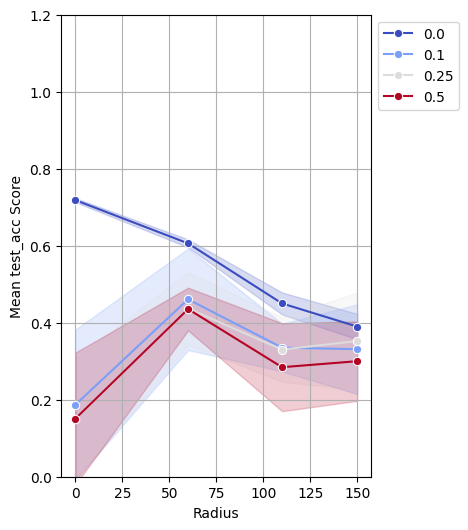

In [10]:
GNN_wandb.plot_robustness(metric="test_acc", save_path = f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/node_class")

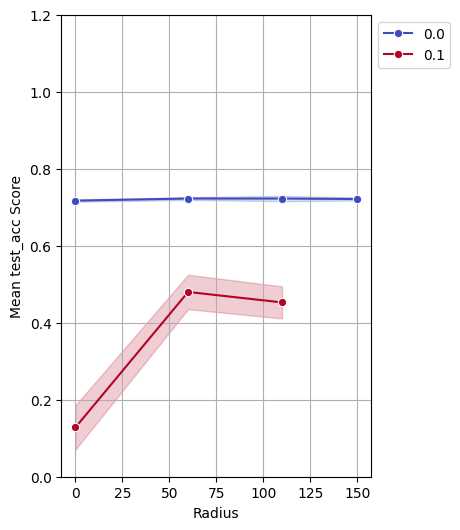

In [11]:
DualInterScale_wandb.plot_robustness(metric="test_acc", save_path =  f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/node_class")

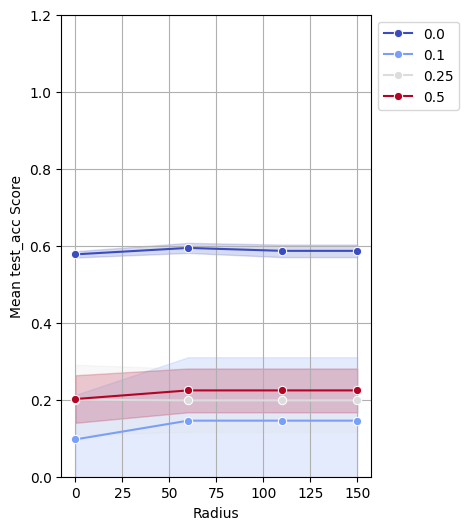

In [12]:
PCATrans_wandb.plot_robustness(metric="test_acc", save_path =  f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/node_class")

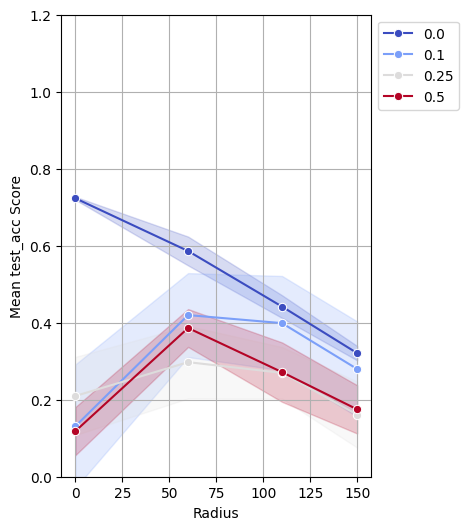

In [13]:
InterScale_wandb.plot_robustness(metric="test_acc", save_path =  f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/node_class")

## F1 score performance

In [14]:
wandb_evals = [GNN_wandb, PCATrans_wandb, DualInterScale_wandb]  # Your list of dataframes, PCATrans_wandb, InterScale_wandb

## Class robustness

             model                      class      mean       std  n_seeds
0   DualInterScale       test_f1_class_Acinar  0.753935  0.005037        5
1   DualInterScale        test_f1_class_Alpha  0.674761  0.008327        5
2   DualInterScale         test_f1_class_Beta  0.587428  0.008500        5
3   DualInterScale       test_f1_class_Ductal  0.767753  0.008048        5
4   DualInterScale    test_f1_class_Endocrine  0.600121  0.062506        5
5   DualInterScale  test_f1_class_Endothelial  0.540104  0.016871        5
6   DualInterScale       test_f1_class_Immune  0.602552  0.009768        5
7   DualInterScale         test_f1_class_Mast  0.332355  0.017566        5
8              GCN       test_f1_class_Acinar  0.727350  0.006129        5
9              GCN        test_f1_class_Alpha  0.613468  0.008930        5
10             GCN         test_f1_class_Beta  0.501538  0.016221        5
11             GCN       test_f1_class_Ductal  0.683530  0.006784        5
12             GCN    tes

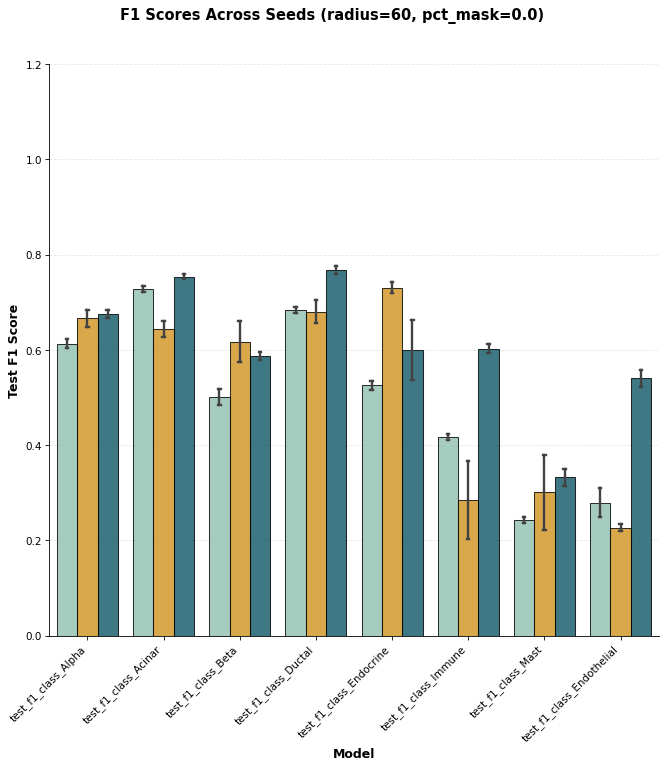

In [17]:
g, stats, plot_data = plot_f1_across_seeds(
    wandb_evaluations=wandb_evals,
    radius=60,
    pct_mask_nodes=0.0,
    BASE_DIR_REPO=BASE_DIR_REPO, 
    height=10,
    aspect=0.9,
    save_path=f'{DATA}/node_class/f1_comparison_models_radius'
)
plt.show()
#
# # Save with high DPI from config
# # g.savefig('f1_scores.png', bbox_inches='tight')
#
# # Print statistics:
# print(stats)

In [19]:
from src.wandb import plot_class_f1_robustness

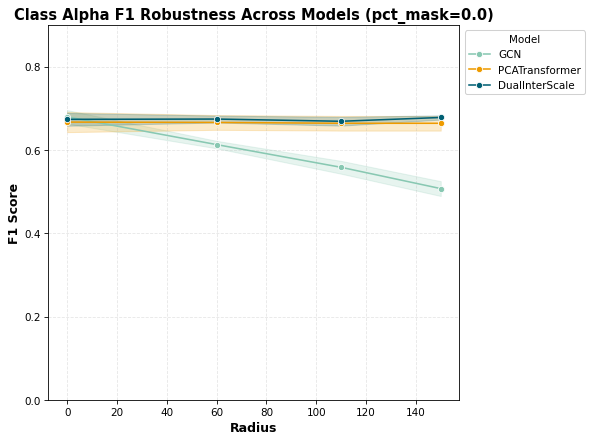


Statistics Summary:
         model  radius     mean      std  n_seeds
DualInterScale       0 0.674089 0.015360        5
DualInterScale      60 0.674761 0.008327        5
DualInterScale     110 0.669443 0.010484        5
DualInterScale     150 0.678539 0.005078        5
           GCN       0 0.679982 0.016222        5
           GCN      60 0.613468 0.008930        5
           GCN     110 0.558882 0.015385        5
           GCN     150 0.507770 0.017770        5
PCATransformer       0 0.667466 0.024096        5
PCATransformer      60 0.666606 0.017713        5
PCATransformer     110 0.664615 0.017622        5
PCATransformer     150 0.664615 0.017622        5


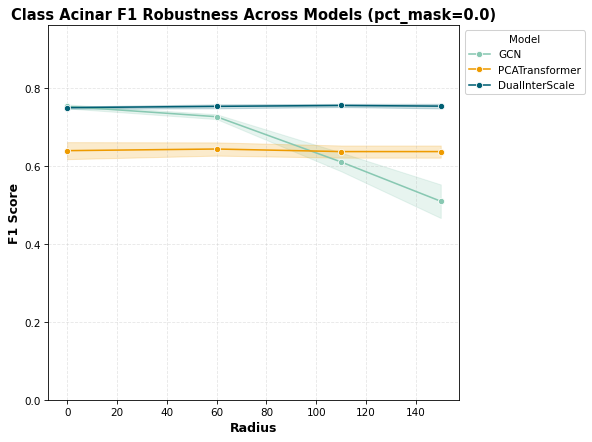


Statistics Summary:
         model  radius     mean      std  n_seeds
DualInterScale       0 0.750662 0.002667        5
DualInterScale      60 0.753935 0.005037        5
DualInterScale     110 0.756177 0.004049        5
DualInterScale     150 0.754507 0.005869        5
           GCN       0 0.753756 0.005046        5
           GCN      60 0.727350 0.006129        5
           GCN     110 0.611179 0.023872        5
           GCN     150 0.510362 0.042991        5
PCATransformer       0 0.640212 0.021847        5
PCATransformer      60 0.644392 0.016974        5
PCATransformer     110 0.637815 0.015616        5
PCATransformer     150 0.637815 0.015616        5


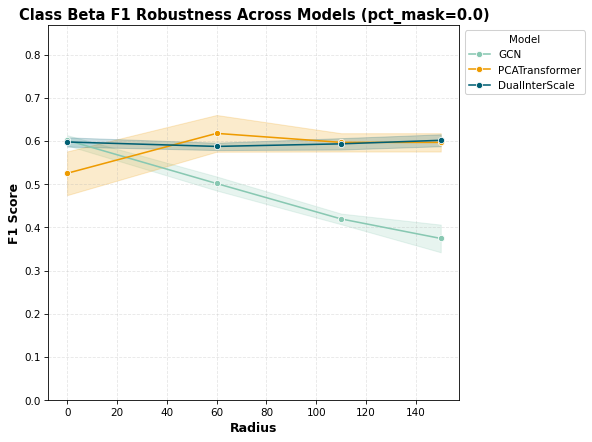


Statistics Summary:
         model  radius     mean      std  n_seeds
DualInterScale       0 0.597699 0.010721        5
DualInterScale      60 0.587428 0.008500        5
DualInterScale     110 0.593383 0.013176        5
DualInterScale     150 0.601600 0.013773        5
           GCN       0 0.601618 0.011796        5
           GCN      60 0.501538 0.016221        5
           GCN     110 0.419476 0.012339        5
           GCN     150 0.374279 0.032005        5
PCATransformer       0 0.525185 0.050572        5
PCATransformer      60 0.617645 0.042516        5
PCATransformer     110 0.596784 0.021216        5
PCATransformer     150 0.596784 0.021216        5


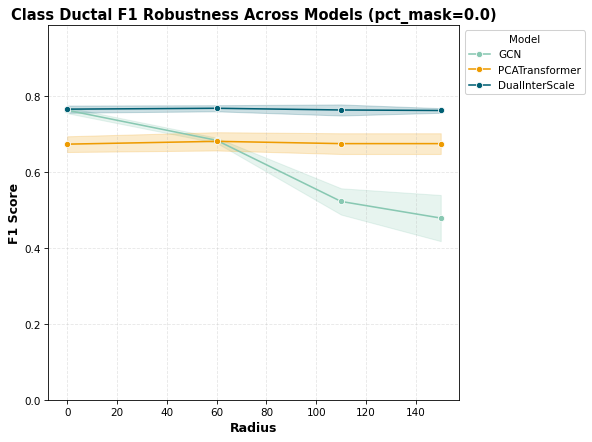


Statistics Summary:
         model  radius     mean      std  n_seeds
DualInterScale       0 0.765428 0.009426        5
DualInterScale      60 0.767753 0.008048        5
DualInterScale     110 0.763258 0.014561        5
DualInterScale     150 0.761931 0.006094        5
           GCN       0 0.762645 0.007836        5
           GCN      60 0.683530 0.006784        5
           GCN     110 0.522545 0.034602        5
           GCN     150 0.478884 0.060649        5
PCATransformer       0 0.673340 0.020720        5
PCATransformer      60 0.680748 0.024052        5
PCATransformer     110 0.674726 0.027281        5
PCATransformer     150 0.674726 0.027281        5


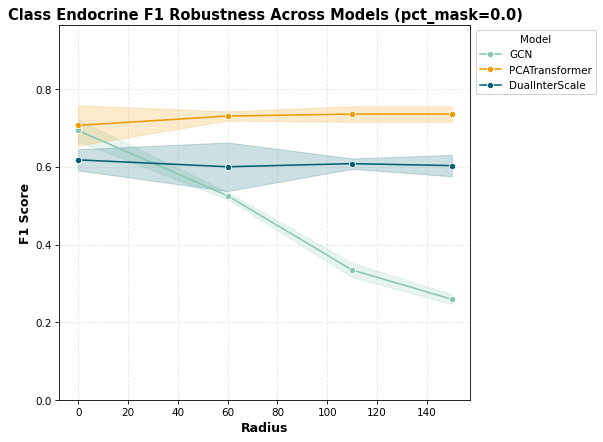


Statistics Summary:
         model  radius     mean      std  n_seeds
DualInterScale       0 0.617924 0.027193        5
DualInterScale      60 0.600121 0.062506        5
DualInterScale     110 0.608120 0.013404        5
DualInterScale     150 0.603093 0.027647        5
           GCN       0 0.693538 0.027757        5
           GCN      60 0.525551 0.009358        5
           GCN     110 0.334599 0.018274        5
           GCN     150 0.259444 0.012456        5
PCATransformer       0 0.706454 0.051681        5
PCATransformer      60 0.730658 0.011922        5
PCATransformer     110 0.735669 0.019938        5
PCATransformer     150 0.735669 0.019938        5


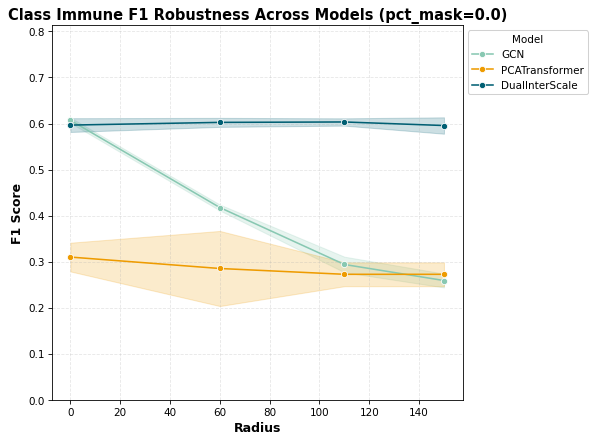


Statistics Summary:
         model  radius     mean      std  n_seeds
DualInterScale       0 0.596690 0.014949        5
DualInterScale      60 0.602552 0.009768        5
DualInterScale     110 0.603445 0.007938        5
DualInterScale     150 0.595730 0.017776        5
           GCN       0 0.607155 0.005815        5
           GCN      60 0.417801 0.006400        5
           GCN     110 0.294205 0.016902        5
           GCN     150 0.259348 0.014971        5
PCATransformer       0 0.310268 0.031173        5
PCATransformer      60 0.285469 0.081483        5
PCATransformer     110 0.272864 0.025850        5
PCATransformer     150 0.272864 0.025850        5


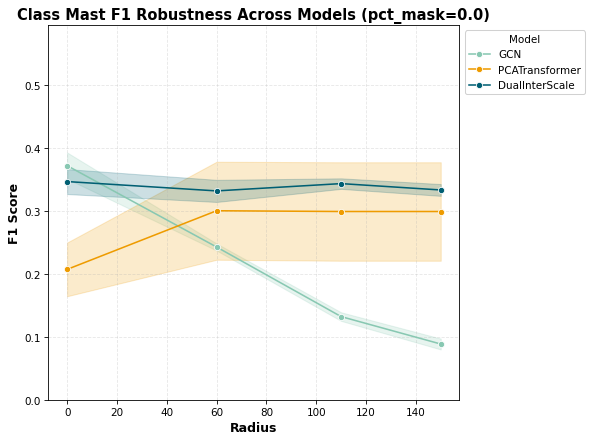


Statistics Summary:
         model  radius     mean      std  n_seeds
DualInterScale       0 0.347198 0.019821        5
DualInterScale      60 0.332355 0.017566        5
DualInterScale     110 0.343960 0.008378        5
DualInterScale     150 0.333840 0.009375        5
           GCN       0 0.372470 0.020903        5
           GCN      60 0.243220 0.005555        5
           GCN     110 0.132615 0.006812        5
           GCN     150 0.089027 0.008616        5
PCATransformer       0 0.207642 0.042657        5
PCATransformer      60 0.300824 0.077864        5
PCATransformer     110 0.299629 0.078248        5
PCATransformer     150 0.299629 0.078248        5


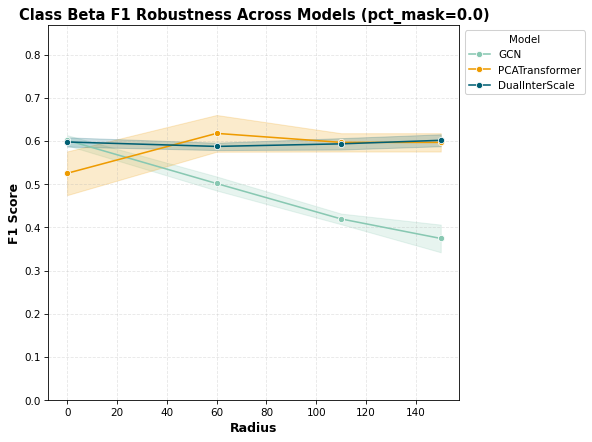


Statistics Summary:
         model  radius     mean      std  n_seeds
DualInterScale       0 0.597699 0.010721        5
DualInterScale      60 0.587428 0.008500        5
DualInterScale     110 0.593383 0.013176        5
DualInterScale     150 0.601600 0.013773        5
           GCN       0 0.601618 0.011796        5
           GCN      60 0.501538 0.016221        5
           GCN     110 0.419476 0.012339        5
           GCN     150 0.374279 0.032005        5
PCATransformer       0 0.525185 0.050572        5
PCATransformer      60 0.617645 0.042516        5
PCATransformer     110 0.596784 0.021216        5
PCATransformer     150 0.596784 0.021216        5


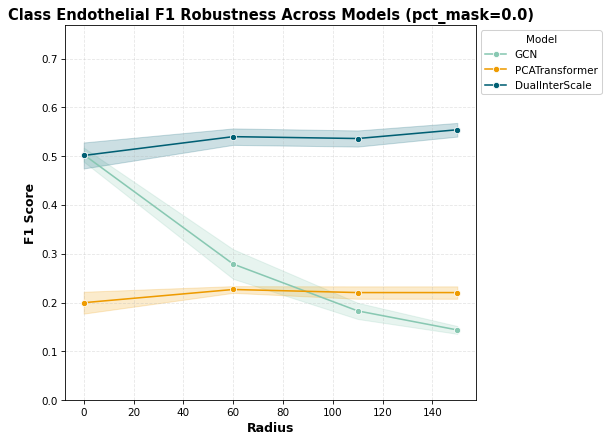


Statistics Summary:
         model  radius     mean      std  n_seeds
DualInterScale       0 0.501508 0.026661        5
DualInterScale      60 0.540104 0.016871        5
DualInterScale     110 0.536273 0.016545        5
DualInterScale     150 0.554247 0.014039        5
           GCN       0 0.503253 0.014384        5
           GCN      60 0.278881 0.030313        5
           GCN     110 0.182814 0.016576        5
           GCN     150 0.143735 0.007991        5
PCATransformer       0 0.199615 0.022380        5
PCATransformer      60 0.226699 0.006899        5
PCATransformer     110 0.220379 0.012700        5
PCATransformer     150 0.220379 0.012700        5


In [20]:
for class_id in CLASSES: 
    fig, ax, stats = plot_class_f1_robustness(
        wandb_evals,
        class_idx=class_id,
        pct_mask_nodes=0.0,
        BASE_DIR_REPO=BASE_DIR_REPO, 
        save_path=f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/node_class"
    )